<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل شانزدهم: الگوریتم‌های یادگیری بدون ناظر (خوشه‌بندی)  </h2>
</div>

<div dir="rtl" align="right">

# مثال تکمیلی DBSCAN برای ایستگاه‌های هواشناسی

دو فایل DBSCAN ارسالی بخش‌های مقدماتی مشترک داشتند؛ این نوت‌بوک مسیر کامل آن‌ها را یکپارچه می‌کند. ایستگاه‌ها بر اساس دما و موقعیت، و سپس با افزودن بارش، گروه‌بندی می‌شوند. این مثال مستقل از مثال قبلیِ مناطق شیکاگو است.

</div>

<div dir="rtl" align="right">

## آماده‌سازی
سلول‌ها را از بالا به پایین اجرا کنید. فایل‌های داده در پوشهٔ `data` قرار دارند. وابستگی‌ها در `requirements.txt` مشخص شده‌اند.

</div>

In [1]:
# آماده‌سازی
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# پوشهٔ داده کنار پوشهٔ نوت‌بوک‌ها قرار دارد.
DATA = Path("../data")
if not DATA.is_dir():
    DATA = Path("data")
if not DATA.is_dir():
    raise FileNotFoundError("Open notebook from the extracted bundle.")
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

<div dir="rtl" align="right">

## 1. خواندن داده و تعیین محدوده

Tm میانگین دما، Tx بیشینه و Tn کمینهٔ دما هستند. ایستگاه‌هایی که این مقادیر یا مختصات را ندارند در این تحلیل وارد نمی‌شوند.

</div>

In [2]:
# خواندن داده و تعیین محدوده
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

weather = pd.read_csv(DATA / "weather-stations.csv")
required = ["Tm", "Tx", "Tn", "Lat", "Long"]
work = weather.dropna(subset=required).copy()
work = work.loc[work["Long"].between(-140, -50, inclusive="neither") &
                work["Lat"].between(40, 75, inclusive="neither")].copy()
print("Raw:", len(weather), "Included:", len(work))

Raw: 1341 Included: 1244


<div dir="rtl" align="right">

## 2. نمایش موقعیت در تصویر مرکاتور

برای حفظ تعریف مکانی مثال اصلی، مختصات مرکاتور با فرمول کروی محاسبه می‌شود. پس از استانداردسازی هر ستون، ضریب ثابت شعاع زمین و انتقال مبدأ بر فاصله‌ها اثر ندارند. نمودار، پراکنش مختصات است و نقشهٔ مرزهای کشورها نیست.

</div>

In [3]:
# عرض‌های انتخاب‌شده از قطب‌ها فاصله دارند.
work["xm"] = np.deg2rad(work["Long"])
work["ym"] = np.log(np.tan(np.pi / 4 + np.deg2rad(work["Lat"]) / 2))
features = ["Tm", "Tx", "Tn", "xm", "ym"]
X = StandardScaler().fit_transform(work[features])
model = DBSCAN(eps=0.3, min_samples=10).fit(X)
work["Cluster"] = model.labels_
print("Clusters:", len(set(model.labels_) - {-1}))
print("Noise:", (model.labels_ == -1).sum())
display(work.groupby("Cluster")["Tm"].agg(["size", "mean"]).round(2))

Clusters: 8
Noise: 384


,size,mean
Cluster,,
-1,384,-17.74
0,177,6.24
1,21,-0.55
2,9,-3.24
3,255,-13.73
4,54,-4.15
5,309,-16.40
6,19,-10.08
7,16,-4.71


<div dir="rtl" align="right">

## 3. دیدن خوشه‌ها و نقاط نویز

برچسب منفی یک یعنی ایستگاه با این تنظیمات عضو هیچ خوشه‌ای نشده است. شعاع ۰٫۳ در فضای استانداردشدهٔ پنج ویژگی تعریف می‌شود و کیلومتر نیست.

</div>

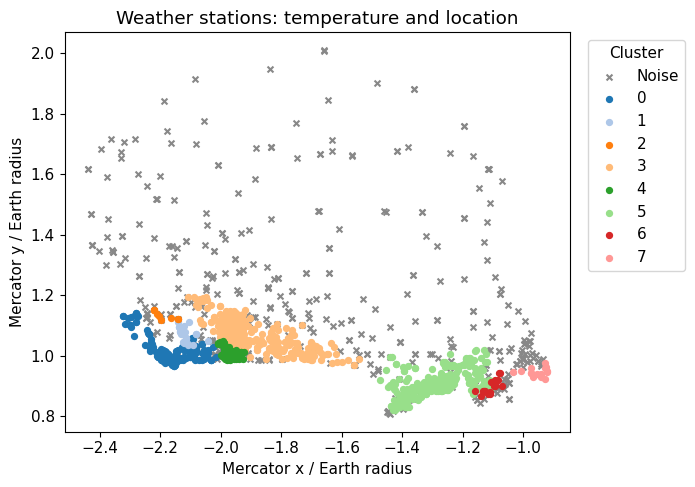

In [4]:
# دیدن خوشه‌ها و نقاط نویز
def plot_clusters(frame, label, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    groups = sorted(frame[label].unique())
    colors = plt.get_cmap("tab20")
    for group in groups:
        part = frame.loc[frame[label] == group]
        color = "#888888" if group == -1 else colors(int(group) % 20)
        ax.scatter(part["xm"], part["ym"], s=18, color=color,
                   marker="x" if group == -1 else "o",
                   label="Noise" if group == -1 else str(group))
    ax.set(xlabel="Mercator x / Earth radius",
           ylabel="Mercator y / Earth radius", title=title)
    ax.set_aspect("equal")
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

plot_clusters(work, "Cluster", "Weather stations: temperature and location")

<div dir="rtl" align="right">

## 4. افزودن بارش به ویژگی‌ها

P بارش کل است. فقط ردیف‌های دارای P استفاده می‌شوند و مقیاس‌ساز برای همین جدول از نو برازش می‌شود. هم ویژگی‌ها و هم eps عوض شده‌اند؛ تغییر نتیجه را نمی‌توان فقط به بارش نسبت داد.

</div>

In [5]:
# افزودن بارش به ویژگی‌ها
with_rain = work.dropna(subset=["P"]).copy()
X_rain = StandardScaler().fit_transform(with_rain[features + ["P"]])
rain_model = DBSCAN(eps=0.5, min_samples=10).fit(X_rain)
with_rain["Rain_cluster"] = rain_model.labels_
print("Included with precipitation:", len(with_rain))
print("Clusters:", len(set(rain_model.labels_) - {-1}))
print("Noise:", (rain_model.labels_ == -1).sum())
display(with_rain.groupby("Rain_cluster")[["Tm", "P"]].mean().round(2))

Included with precipitation: 1136
Clusters: 4
Noise: 278


,Tm,P
Rain_cluster,,
-1,-13.43,80.65
0,7.68,126.10
1,-12.53,27.42
2,-26.14,8.70
3,-10.41,146.02


<div dir="rtl" align="right">

## 5. نمودارِ مرحلهٔ بارش

ردیف‌ها و برچسب‌ها از همان جدول with_rain گرفته می‌شوند تا حذف دادهٔ گمشده باعث جابه‌جایی برچسب‌ها نشود.

</div>

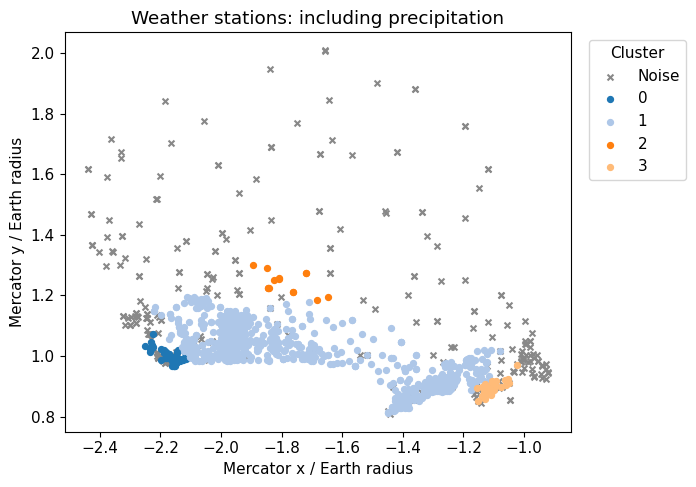

In [6]:
# نمودارِ مرحلهٔ بارش
plot_clusters(with_rain, "Rain_cluster", "Weather stations: including precipitation")

<div dir="rtl" align="right">

## نکتهٔ پایانی
در مرحلهٔ نخست ۸ خوشه و ۳۸۴ نقطهٔ نویز به دست می‌آید. برچسب منفی یک یعنی ایستگاه با این تنظیمات عضو خوشه نشده است. min_samples خود نقطه را نیز می‌شمارد. این نتیجه شباهت در ویژگی‌های انتخاب‌شده را توصیف می‌کند و تقسیم‌بندی رسمی اقلیم نیست.

</div>

<div dir="rtl" align="right">

## مأخذ مثال
مراجع فنی: [scikit-learn](https://scikit-learn.org/1.8/user_guide.html)، [pandas](https://pandas.pydata.org/docs/)، [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html).

</div>